# Recommendation System

В этом ноутбуке строится простой recommender для Airbnb listings. Идея такая: если пользователь смотрит один объект, мы хотим найти другие объекты, которые похожи на него по цене, типу жилья, району, удобствам и смыслу отзывов.

Это **content-based recommender**. Он не использует историю кликов или бронирований пользователей. Вместо этого он сравнивает сами listings: их числовые признаки, категории, amenities и review embeddings.

Что получится на выходе:
- матрица похожести `data/processed/X_combined.npy`;
- nearest-neighbor индекс `models/recommender_nn.pkl`;
- функция `recommend(listing_id, n=10)`, которая возвращает похожие listings.


## Setup


In [1]:
# Базовые настройки и загрузка данных
import os, pickle, warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")

PROCESSED = Path("../data/processed")
MODELS = Path("../models")

lf = pd.read_parquet(PROCESSED / "listings_features.parquet").reset_index(drop=True)
emb = np.load(PROCESSED / "review_embeddings.npy")
emb_ids = pd.read_parquet(PROCESSED / "review_embeddings_ids.parquet").reset_index(drop=True)

if len(emb) != len(emb_ids):
    raise ValueError("review_embeddings и review_embeddings_ids имеют разную длину")

print(f"listings    : {lf.shape}")
print(f"review embs : {emb.shape}")


listings    : (5844, 107)
review embs : (9383, 384)


## Feature Blocks

Мы не складываем все признаки в одну кучу сразу. Сначала собираем несколько блоков:
- **числовой блок**: цена, размер жилья, расстояние до центра, рейтинг;
- **категориальный блок**: тип комнаты, тип жилья, район;
- **amenities block**: флаги вроде `has_wifi`, `has_kitchen`;
- **review embeddings**: векторы из отзывов, которые дают смысловой сигнал.

recommender сравнивает listings сразу по нескольким сторонам, а не только по цене или району.


In [2]:
# Собираем блоки признаков
num_cols = ["price", "accommodates", "bedrooms", "distance_to_center", "review_scores_rating"]
cat_cols = ["room_type", "property_type_grp", "neighbourhood_cleansed"]
amen_cols = sorted(col for col in lf.columns if col.startswith("has_"))

scaler_num = StandardScaler()
X_num = scaler_num.fit_transform(lf[num_cols].fillna(lf[num_cols].median()))

X_cat_df = pd.get_dummies(lf[cat_cols].fillna("unknown"), drop_first=True).astype(float)
X_cat = X_cat_df.to_numpy()

X_amen = lf[amen_cols].fillna(0).astype(float).to_numpy()

emb_df = pd.DataFrame(emb)
emb_df["listing_id"] = emb_ids["listing_id"].to_numpy()
emb_df = emb_df.groupby("listing_id", as_index=False).mean()
merged_emb = lf[["id"]].merge(emb_df, left_on="id", right_on="listing_id", how="left")
X_review = merged_emb.drop(columns=["id", "listing_id"]).fillna(0).to_numpy(dtype=float)

embedding_coverage = merged_emb["listing_id"].notna().mean()
block_shapes = pd.DataFrame([
    ("num", X_num.shape[1]),
    ("cat", X_cat.shape[1]),
    ("amen", X_amen.shape[1]),
    ("review", X_review.shape[1]),
], columns=["block", "n_features"])

print(f"review embeddings coverage: {embedding_coverage:.1%}")
display(block_shapes)


review embeddings coverage: 89.0%


,block,n_features
0,num,5
1,cat,27
2,amen,12
3,review,384


### Графики: состав признаков


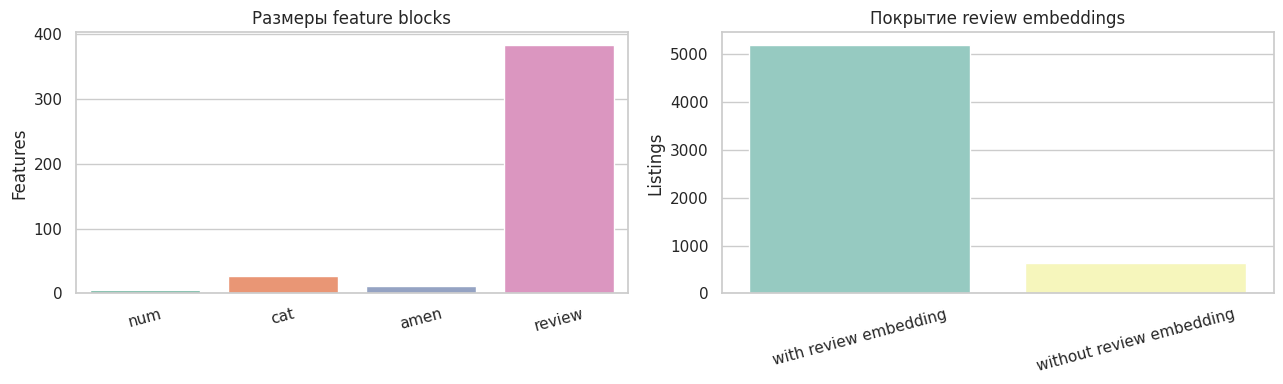

In [3]:
# Смотрим, из чего состоит будущий вектор похожести
coverage_df = pd.DataFrame({
    "status": ["with review embedding", "without review embedding"],
    "listings": [merged_emb["listing_id"].notna().sum(), merged_emb["listing_id"].isna().sum()],
})

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=block_shapes, x="block", y="n_features", palette="Set2", ax=ax[0])
ax[0].set(title="Размеры feature blocks", xlabel="", ylabel="Features")

sns.barplot(data=coverage_df, x="status", y="listings", palette="Set3", ax=ax[1])
ax[1].set(title="Покрытие review embeddings", xlabel="", ylabel="Listings")
for axis in ax:
    axis.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


## Weighted Vector

Теперь соединяем блоки в один общий вектор `X_combined`. Перед объединением каждому блоку задаётся вес.

Простая интуиция:
- числовые признаки оставляем самыми сильными;
- категории и amenities тоже важны, но чуть слабее;
- review embeddings полезны, но могут быть шумными, поэтому их вес ниже.


In [4]:
# Объединяем блоки с фиксированными весами
WEIGHTS = {"num": 1.0, "cat": 0.7, "amen": 0.8, "review": 0.6}
blocks = {"num": X_num, "cat": X_cat, "amen": X_amen, "review": X_review}

X_combined = np.hstack([blocks[name] * WEIGHTS[name] for name in WEIGHTS])
np.save(PROCESSED / "X_combined.npy", X_combined)

block_summary = pd.DataFrame([
    {
        "block": name,
        "features": blocks[name].shape[1],
        "weight": WEIGHTS[name],
        "mean_weighted_norm": np.linalg.norm(blocks[name] * WEIGHTS[name], axis=1).mean(),
    }
    for name in WEIGHTS
])

print(f"X_combined: {X_combined.shape}")
display(block_summary.round(3))


X_combined: (5844, 428)


,block,features,weight,mean_weighted_norm
0,num,5,1.0,1.903
1,cat,27,0.7,0.847
2,amen,12,0.8,1.807
3,review,384,0.6,0.534


### График: вклад блоков после весов


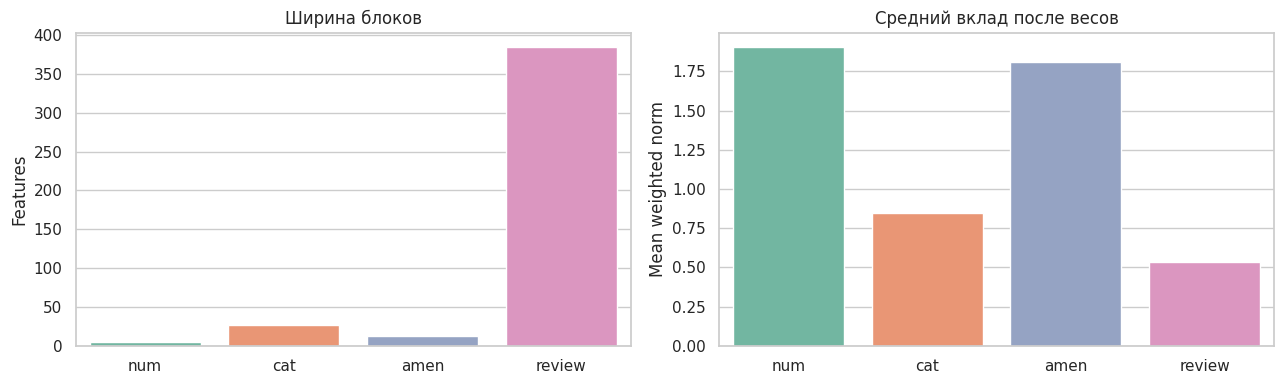

In [5]:
# Вес блока удобнее читать через среднюю L2-норму после умножения
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=block_summary, x="block", y="features", palette="Set2", ax=ax[0])
ax[0].set(title="Ширина блоков", xlabel="", ylabel="Features")

sns.barplot(data=block_summary, x="block", y="mean_weighted_norm", palette="Set2", ax=ax[1])
ax[1].set(title="Средний вклад после весов", xlabel="", ylabel="Mean weighted norm")

plt.tight_layout()
plt.show()


## Nearest Neighbors Index

Дальше используем `NearestNeighbors`. Он не обучает сложную модель, а просто запоминает все векторы и умеет быстро искать ближайшие.

Метрика `cosine` сравнивает направление векторов. Для широких feature vectors это часто удобнее, чем обычное евклидово расстояние.


In [6]:
# Индекс ближайших соседей
nn = NearestNeighbors(n_neighbors=11, metric="cosine").fit(X_combined)
id_to_idx = pd.Series(lf.index, index=lf["id"]).to_dict()
listing_lookup = lf.set_index("id")

print(nn)


NearestNeighbors(metric='cosine', n_neighbors=11)


## Recommend Function

Функция сначала берёт ближайшие listings по cosine similarity, а потом применяет простые бизнес-фильтры:
- оставить тот же `room_type`;
- оставить похожий ценовой диапазон;
- при необходимости оставить тот же `geo_cluster`.

Это важно: ML находит похожесть, а фильтры делают результат более понятным для пользователя.


In [7]:
# Функция рекомендаций с простыми бизнес-фильтрами
REC_COLS = ["id", "room_type", "neighbourhood_cleansed", "price", "review_scores_rating", "similarity"]


def recommend(listing_id, n=10, same_room_type=True, price_band=0.3, same_geo_cluster=False, max_candidates=200):
    if listing_id not in id_to_idx:
        return pd.DataFrame(columns=REC_COLS)

    idx = id_to_idx[listing_id]
    k = min(max_candidates + 1, len(lf))
    dists, idxs = nn.kneighbors(X_combined[idx:idx + 1], n_neighbors=k)

    recs = lf.iloc[idxs[0]].copy()
    recs["similarity"] = 1 - dists[0]
    recs = recs[recs["id"].ne(listing_id)]

    src = lf.iloc[idx]
    if same_room_type:
        recs = recs[recs["room_type"].eq(src["room_type"])]
    if price_band is not None:
        lo, hi = src["price"] * (1 - price_band), src["price"] * (1 + price_band)
        recs = recs[recs["price"].between(lo, hi)]
    if same_geo_cluster and "geo_cluster" in recs.columns:
        recs = recs[recs["geo_cluster"].eq(src["geo_cluster"])]

    return recs.head(n)[REC_COLS].reset_index(drop=True)

example_id = lf["id"].iloc[0]
display(recommend(example_id, n=5).round(3))


,id,room_type,neighbourhood_cleansed,price,review_scores_rating,similarity
0,17603122,Private room,Centrum-West,137.0,4.96,0.863
1,48028679,Private room,Centrum-West,158.0,4.88,0.852
2,29871927,Private room,Oostelijk Havengebied - Indische Buurt,150.0,4.98,0.847
3,4721743,Private room,Centrum-West,122.0,4.88,0.819
4,771343,Private room,Centrum-West,122.0,4.91,0.818


### Графики: пример рекомендаций


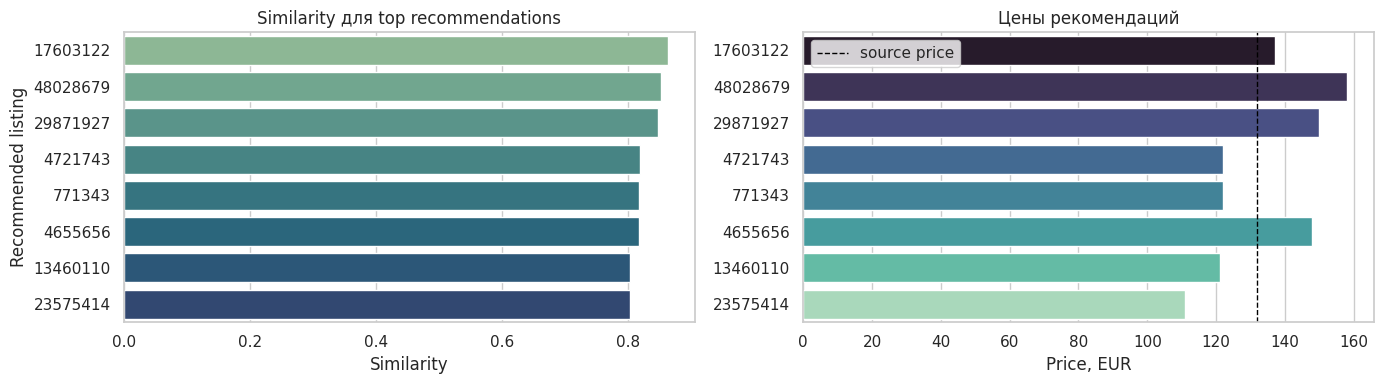

In [8]:
# Один пример: похожесть и цены рекомендаций
example_recs = recommend(example_id, n=8)
source_price = lf.loc[id_to_idx[example_id], "price"]

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=example_recs, x="similarity", y=example_recs["id"].astype(str), palette="crest", ax=ax[0])
ax[0].set(title="Similarity для top recommendations", xlabel="Similarity", ylabel="Recommended listing")

price_plot = example_recs[["id", "price"]].copy()
price_plot["id"] = price_plot["id"].astype(str)
sns.barplot(data=price_plot, x="price", y="id", palette="mako", ax=ax[1])
ax[1].axvline(source_price, color="black", linestyle="--", linewidth=1, label="source price")
ax[1].set(title="Цены рекомендаций", xlabel="Price, EUR", ylabel="")
ax[1].legend()

plt.tight_layout()
plt.show()


## Quality Check

У recommender без кликов и бронирований нет идеальной метрики качества. Поэтому используем простые проверки:
- **same-host hit-rate@10**: если у хоста несколько объектов, попадает ли похожий объект того же хоста в top-10;
- **price coherence**: насколько рекомендации близки по цене;
- **neighbourhood diversity**: рекомендации приходят из одного района или из разных;
- **room type match**: насколько часто совпадает тип комнаты.

Это не финальная business evaluation, но хороший sanity check  (для учебного проекта)


In [9]:
# Считаем простые метрики качества

def evaluate_ids(ids, n=10):
    rows = []
    for listing_id in ids:
        recs = recommend(listing_id, n=n, same_room_type=False, price_band=None)
        if len(recs) < 2:
            continue

        src = lf.loc[id_to_idx[listing_id]]
        rec_host_ids = listing_lookup.loc[recs["id"], "host_id"].to_numpy()
        rows.append({
            "listing_id": listing_id,
            "mean_similarity": recs["similarity"].mean(),
            "neighbourhood_diversity": recs["neighbourhood_cleansed"].nunique() / len(recs),
            "price_delta_mean": (recs["price"] - src["price"]).abs().mean() / max(src["price"], 1),
            "room_type_match": recs["room_type"].eq(src["room_type"]).mean(),
            "same_host_hit": int((rec_host_ids == src["host_id"]).any()),
        })
    return pd.DataFrame(rows)

sample_ids = lf["id"].sample(200, random_state=SEED)
eval_df = evaluate_ids(sample_ids)

host_counts = lf["host_id"].value_counts()
multi_host_ids = host_counts[host_counts >= 2].index
multi_listing_ids = lf.loc[lf["host_id"].isin(multi_host_ids), "id"].sample(200, random_state=SEED)
host_eval_df = evaluate_ids(multi_listing_ids)

metrics = pd.DataFrame([
    ("same_host_hit_rate@10", host_eval_df["same_host_hit"].mean()),
    ("neighbourhood_diversity@10", eval_df["neighbourhood_diversity"].mean()),
    ("price_delta_mean@10", eval_df["price_delta_mean"].mean()),
    ("room_type_match@10", eval_df["room_type_match"].mean()),
    ("mean_similarity@10", eval_df["mean_similarity"].mean()),
], columns=["metric", "value"])

display(metrics.assign(value=metrics["value"].round(3)))


,metric,value
0,same_host_hit_rate@10,0.700
1,neighbourhood_diversity@10,0.256
2,price_delta_mean@10,0.228
3,room_type_match@10,0.910
4,mean_similarity@10,0.882


### Графики: метрики качества


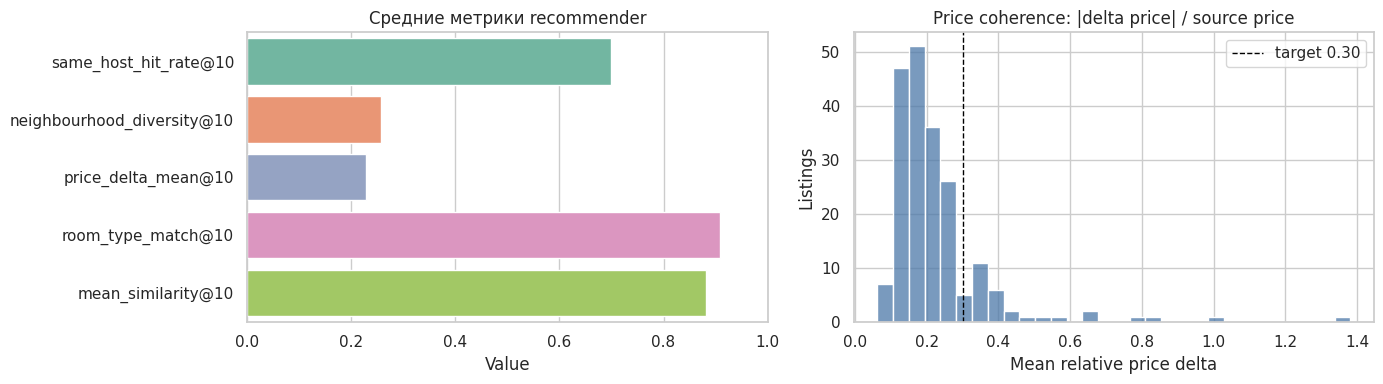

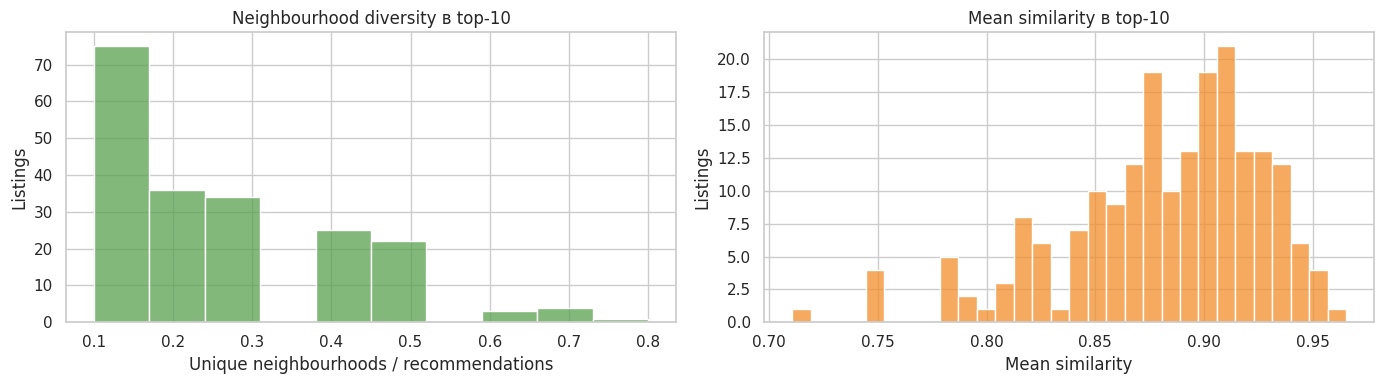

In [10]:
# Метрики в целом и распределения по sample
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=metrics, y="metric", x="value", palette="Set2", ax=ax[0])
ax[0].set(title="Средние метрики recommender", xlabel="Value", ylabel="", xlim=(0, 1))

sns.histplot(eval_df["price_delta_mean"], bins=30, color="#4C78A8", ax=ax[1])
ax[1].axvline(0.30, color="black", linestyle="--", linewidth=1, label="target 0.30")
ax[1].set(title="Price coherence: |delta price| / source price", xlabel="Mean relative price delta", ylabel="Listings")
ax[1].legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(eval_df["neighbourhood_diversity"], bins=10, color="#59A14F", ax=ax[0])
ax[0].set(title="Neighbourhood diversity в top-10", xlabel="Unique neighbourhoods / recommendations", ylabel="Listings")

sns.histplot(eval_df["mean_similarity"], bins=30, color="#F28E2B", ax=ax[1])
ax[1].set(title="Mean similarity в top-10", xlabel="Mean similarity", ylabel="Listings")

plt.tight_layout()
plt.show()


### Вывод: качество рекомендаций

Рекомендатель проходит базовый sanity check.

Что видно по метрикам:
- `same_host_hit_rate@10 = 0.70`: для хостов с несколькими объектами похожий объект того же хоста часто попадает в top-10;
- `price_delta_mean@10 = 0.23`: в среднем рекомендации отличаются по цене примерно на 23%, то есть проходят простой benchmark `< 0.30`;
- `neighbourhood_diversity@10 = 0.26`: рекомендации часто остаются в близких или тех же районах, поэтому разнообразие районов невысокое;
- `room_type_match@10 = 0.91`: recommender почти всегда удерживает похожий тип жилья;
- `mean_similarity@10 = 0.88`: ближайшие соседи действительно близки по построенному feature vector.

Система уже умеет находить похожие listings, но это пока не "идеальный recommender". Это хороший baseline, который можно дальше улучшать весами, фильтрами и реальными пользовательскими сигналами.


## Save Artifacts


In [11]:
# Сохраняем индекс и всё, что нужно для повторного использования
artifact = {
    "nn": nn,
    "id_to_idx": id_to_idx,
    "weights": WEIGHTS,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "cat_dummy_cols": X_cat_df.columns.tolist(),
    "amen_cols": amen_cols,
    "scaler_num": scaler_num,
    "feature_shape": X_combined.shape,
}

np.save(PROCESSED / "X_combined.npy", X_combined)
with open(MODELS / "recommender_nn.pkl", "wb") as f:
    pickle.dump(artifact, f)

print("saved:")
print(f"  {PROCESSED / 'X_combined.npy'}")
print(f"  {MODELS / 'recommender_nn.pkl'}")


saved:
  ../data/processed/X_combined.npy
  ../models/recommender_nn.pkl


## Итоги 
В этом ноутбуке был собран content-based recommender для Airbnb listings.

Что сделали:
- превратили каждый listing в общий feature vector из числовых, категориальных, amenities и review-embedding признаков;
- получили `X_combined` размера `5844 x 428`;
- review embeddings покрывают около `89%` listings, для остальных используется нулевой вектор;
- задали простые веса блоков, чтобы разные типы признаков не влияли одинаково вслепую;
- построили `NearestNeighbors` index с cosine similarity;
- написали функцию `recommend`, которая добавляет понятные бизнес-фильтры поверх ML-похожести;
- проверили качество через простые sanity metrics.

Ключевые метрики:
- `same_host_hit_rate@10 = 0.70`;
- `price_delta_mean@10 = 0.23`;
- `neighbourhood_diversity@10 = 0.26`;
- `room_type_match@10 = 0.91`;
- `mean_similarity@10 = 0.88`.

Главный результат: recommender уже выдаёт похожие listings по типу жилья, цене и общему профилю. При этом он остаётся baseline-моделью: в проекте нет реальных кликов, просмотров или бронирований, поэтому качество можно оценивать только косвенно.

Что можно улучшить дальше:
- подобрать веса блоков не вручную, а через validation metric;
- добавить description embeddings, если есть качественные тексты описаний;
- сделать разные режимы рекомендаций: "похожее", "дешевле", "лучше рейтинг", "рядом";
- подключить реальные user interactions, если такие данные появятся.

Сохранённые артефакты:
- `data/processed/X_combined.npy`;
- `models/recommender_nn.pkl`.
